In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from datetime import datetime
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [19]:
# Path to the folder with CSV stock files
stock_folder = '../data/raw/yfinance_data/Data/'
print(f"Looking for CSV files in: {os.path.abspath(stock_folder)}")

# Find all .csv files
stock_files = glob.glob(os.path.join(stock_folder, '*.csv'))
print(f"Found CSV files: {stock_files}")

all_stocks = []
for file in stock_files:
    ticker = os.path.basename(file).replace('.csv', '')
    if ticker.startswith('._'):   # skip Mac resource files
        continue
    print(f"Loading {ticker} from {file}")
    df = pd.read_csv(file)
    # Ensure Date column is proper
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df['Ticker'] = ticker
        all_stocks.append(df)
    else:
        print(f"Warning: No 'Date' column in {ticker}. Columns: {df.columns.tolist()}")

if len(all_stocks) == 0:
    raise ValueError("No stock CSV files loaded. Check folder and file names.")
    
stock_df = pd.concat(all_stocks, ignore_index=True)
print(f"\nCombined shape: {stock_df.shape}")
print(stock_df.head())
print("\nTicker distribution:")
print(stock_df['Ticker'].value_counts())

Looking for CSV files in: c:\Users\Tsi\Downloads\Project\news-sentiment-analysis\data\raw\yfinance_data\Data
Found CSV files: ['../data/raw/yfinance_data/Data\\AAPL.csv', '../data/raw/yfinance_data/Data\\AMZN.csv', '../data/raw/yfinance_data/Data\\GOOG.csv', '../data/raw/yfinance_data/Data\\META.csv', '../data/raw/yfinance_data/Data\\NVDA.csv']
Loading AAPL from ../data/raw/yfinance_data/Data\AAPL.csv
Loading AMZN from ../data/raw/yfinance_data/Data\AMZN.csv
Loading GOOG from ../data/raw/yfinance_data/Data\GOOG.csv
Loading META from ../data/raw/yfinance_data/Data\META.csv
Loading NVDA from ../data/raw/yfinance_data/Data\NVDA.csv

Combined shape: (18019, 7)
        Date     Close      High       Low      Open      Volume Ticker
0 2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200   AAPL
1 2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400   AAPL
2 2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400   AAPL
3 2009-01-07  2.729484  2.774170  2.706990  2.7

In [22]:


news_df = pd.read_csv('../data/raw/newsData/raw_analyst_ratings.csv')
print(f"News data shape: {news_df.shape}")
print("Columns:", news_df.columns.tolist())
news_df.head()

News data shape: (1407328, 6)
Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [26]:
# The date column is already a datetime with timezone. Convert to naive.
# Keep the local time (Eastern) but drop the timezone offset.
news_df['date'] = news_df['date'].dt.tz_localize(None)

# Stock dates are already naive (make sure)
stock_df['Date'] = pd.to_datetime(stock_df['Date']).dt.tz_localize(None)

print(f"News date range: {news_df['date'].min()} to {news_df['date'].max()}")
print(f"Stock date range: {stock_df['Date'].min()} to {stock_df['Date'].max()}")

News date range: 2011-04-27 21:01:48 to 2020-06-11 17:12:35
Stock date range: 2009-01-02 00:00:00 to 2023-12-29 00:00:00


count    55987.000000
mean        80.015254
std         56.126094
min         12.000000
25%         42.000000
50%         63.000000
75%         91.000000
max        512.000000
Name: headline_length, dtype: float64


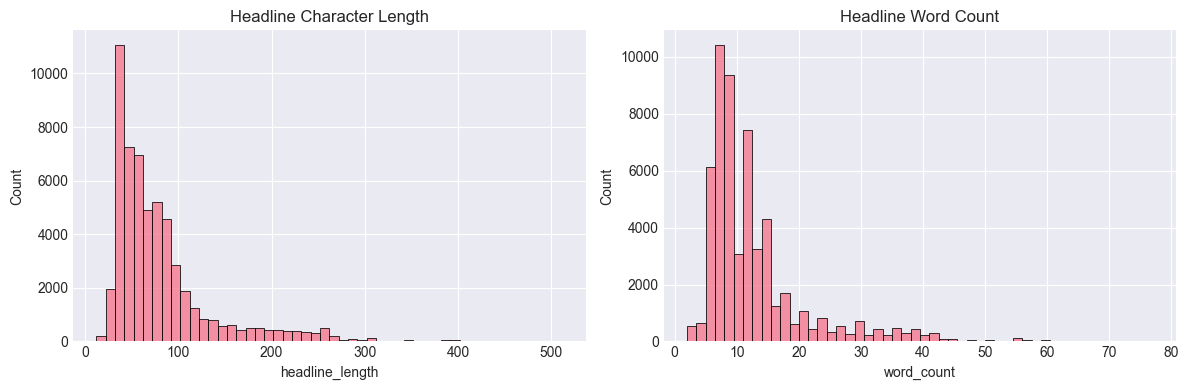

In [27]:
news_df['headline_length'] = news_df['headline'].str.len()
news_df['word_count'] = news_df['headline'].str.split().str.len()

print(news_df['headline_length'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(news_df['headline_length'], bins=50, ax=axes[0])
axes[0].set_title('Headline Character Length')
sns.histplot(news_df['word_count'], bins=50, ax=axes[1])
axes[1].set_title('Headline Word Count')
plt.tight_layout()
plt.savefig('../reports/figures/headline_length_dist.png', dpi=150)
plt.show()

Top 10 publishers:
 publisher
Benzinga Newsdesk    14750
Lisa Levin           12408
ETF Professor         4362
Paul Quintaro         4212
Benzinga Newsdesk     3177
Benzinga Insights     2332
Vick Meyer            2128
Charles Gross         1790
Hal Lindon            1470
Benzinga_Newsdesk     1239
Name: count, dtype: int64

Top 10 domains:
 publisher_domain
Benzinga Newsdesk    14750
Lisa Levin           12408
ETF Professor         4362
Paul Quintaro         4212
Benzinga Newsdesk     3177
Benzinga Insights     2332
Vick Meyer            2128
Charles Gross         1790
Hal Lindon            1470
Benzinga_Newsdesk     1239
Name: count, dtype: int64


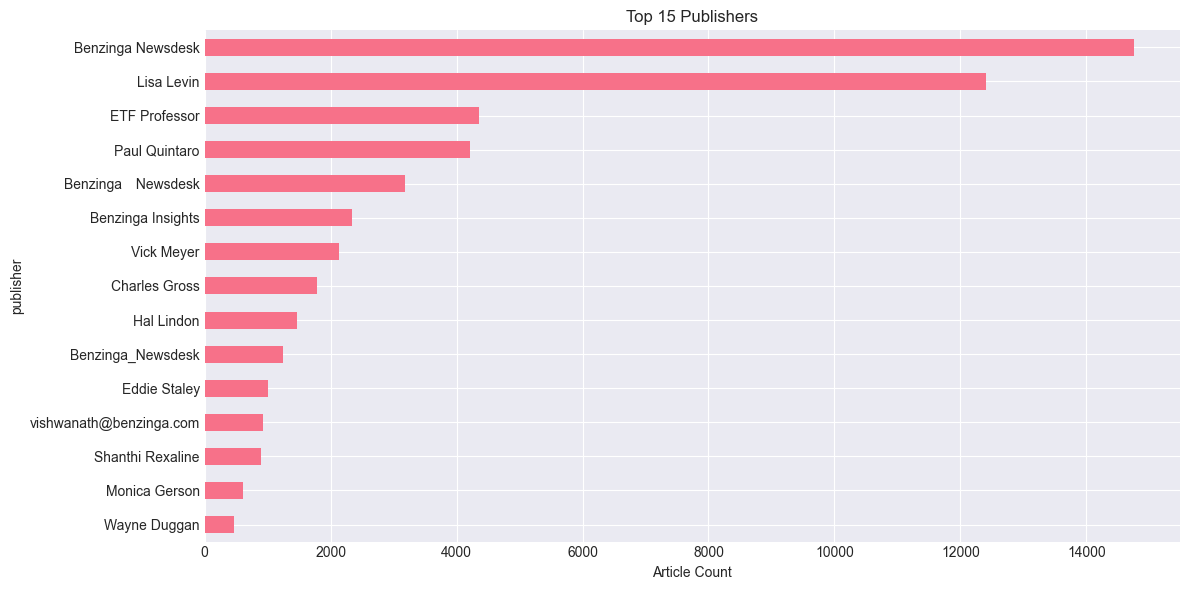

In [28]:
publisher_counts = news_df['publisher'].value_counts()
print("Top 10 publishers:\n", publisher_counts.head(10))

news_df['publisher_domain'] = news_df['publisher'].str.split('@').str[-1]
domain_counts = news_df['publisher_domain'].value_counts().head(10)
print("\nTop 10 domains:\n", domain_counts)

fig, ax = plt.subplots(figsize=(12, 6))
publisher_counts.head(15).plot(kind='barh', ax=ax)
ax.set_title('Top 15 Publishers')
ax.set_xlabel('Article Count')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/top_publishers.png', dpi=150)
plt.show()

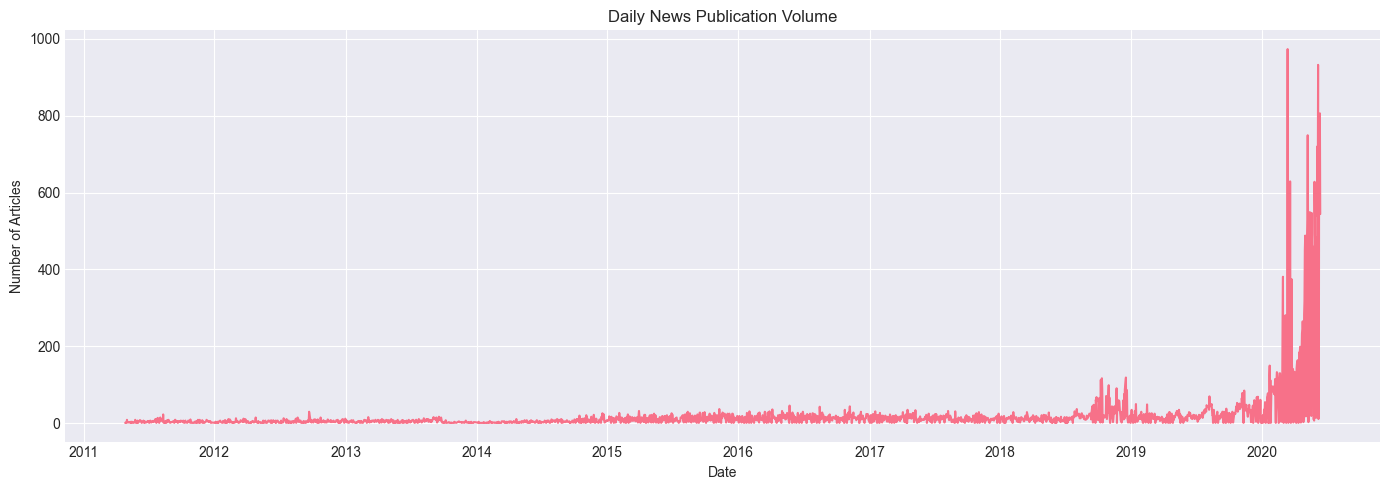

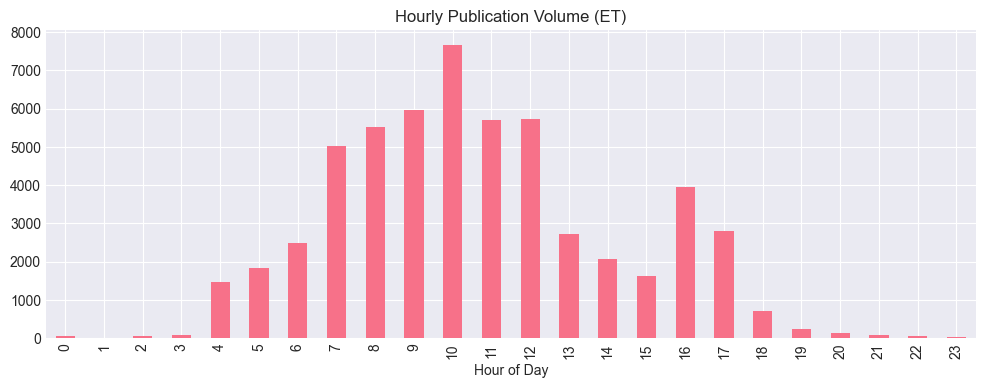

In [29]:
news_df['date_only'] = news_df['date'].dt.date
daily_volume = news_df.groupby('date_only').size()

fig, ax = plt.subplots(figsize=(14, 5))
daily_volume.plot(ax=ax)
ax.set_title('Daily News Publication Volume')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Articles')
plt.tight_layout()
plt.savefig('../reports/figures/daily_volume.png', dpi=150)
plt.show()

news_df['hour'] = news_df['date'].dt.hour
hourly_volume = news_df.groupby('hour').size()
fig, ax = plt.subplots(figsize=(12, 4))
hourly_volume.plot(kind='bar', ax=ax)
ax.set_title('Hourly Publication Volume (ET)')
ax.set_xlabel('Hour of Day')
plt.show()

In [30]:
def preprocess_text(text):
    text = str(text).lower()
    # remove stock tickers like $AAPL
    text = ' '.join([word for word in text.split() if not word.startswith('$')])
    return text

news_df['clean_headline'] = news_df['headline'].apply(preprocess_text)

tfidf = TfidfVectorizer(max_features=100, stop_words='english')
tfidf_matrix = tfidf.fit_transform(news_df['clean_headline'])
feature_names = tfidf.get_feature_names_out()

avg_scores = tfidf_matrix.mean(axis=0).A1
top_indices = avg_scores.argsort()[-20:][::-1]
top_keywords = [(feature_names[i], avg_scores[i]) for i in top_indices]
print("Top 20 keywords:\n", top_keywords)

lda = LatentDirichletAllocation(n_components=8, random_state=42)
lda.fit(tfidf_matrix)

def display_topics(model, feature_names, n_top_words=8):
    topics = []
    for idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[-n_top_words:][::-1]]
        topics.append(f"Topic {idx+1}: {', '.join(top_words)}")
    return topics

print("\nIdentified topics:\n", display_topics(lda, feature_names))

Top 20 keywords:
 [('stocks', np.float64(0.06906777732471489)), ('week', np.float64(0.05485750679061381)), ('52', np.float64(0.05110463306844928)), ('shares', np.float64(0.04761125577068337)), ('hit', np.float64(0.04251672604867507)), ('etfs', np.float64(0.04094434797650042)), ('market', np.float64(0.036415402812788544)), ('price', np.float64(0.03618560749472826)), ('target', np.float64(0.034015179220201926)), ('trading', np.float64(0.03265799794420878)), ('reports', np.float64(0.03195313527107087)), ('eps', np.float64(0.03158175499188312)), ('lows', np.float64(0.031025037179917947)), ('announces', np.float64(0.02725311072870753)), ('etf', np.float64(0.026446904351234177)), ('maintains', np.float64(0.02628659381480313)), ('sales', np.float64(0.025472591615084274)), ('new', np.float64(0.025460327856699577)), ('yesterday', np.float64(0.025375004262459745)), ('thursday', np.float64(0.025329120505505134))]

Identified topics:
 ['Topic 1: week, 52, stocks, hit, lows, highs, new, thursday', 

News articles per stock:
 stock
A       10
AA      10
AAC     10
AAL     10
AAMC    10
AAME    10
AAN     10
AAOI    10
AAON    10
AAP     10
Name: count, dtype: int64


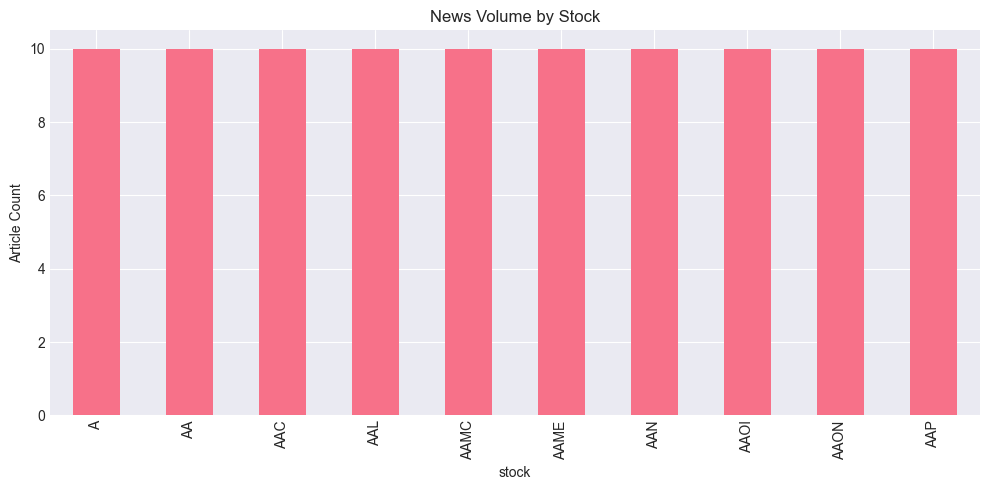

In [31]:
if 'stock' in news_df.columns:
    stock_counts_news = news_df['stock'].value_counts()
    print("News articles per stock:\n", stock_counts_news.head(10))
    fig, ax = plt.subplots(figsize=(10,5))
    stock_counts_news.head(10).plot(kind='bar', ax=ax)
    ax.set_title('News Volume by Stock')
    ax.set_ylabel('Article Count')
    plt.tight_layout()
    plt.savefig('../reports/figures/articles_per_stock.png', dpi=150)
    plt.show()
else:
    print("No 'stock' column in news data. Will attempt to extract from headlines later.")

In [34]:
stock_df.to_csv('../data/processed/stock_combined.csv', index=False)
news_df.to_csv('../data/processed/news_processed.csv', index=False)
print("Processed data saved to CSV format.")

Processed data saved to CSV format.
